# Shap tests using different datasets

In [1]:
import numpy as np
import pandas as pd
import sklearn as skl
import zipfile as zf
import matplotlib.pyplot as plt
import nbimporter
import shap

# Iris dataset

In [2]:
import sklearn.datasets

iris= sklearn.datasets.load_iris()

X_iris= iris.data
Y_iris= iris.target

In [3]:
# convert iris to a df and drop the setosa rows
df_iris= pd.DataFrame(data= np.c_[X_iris, Y_iris], columns= iris['feature_names'] + ['target'])
df_iris= df_iris[df_iris['target']!= 0].reset_index(drop= True)

In [4]:
# split df_iris into features (x) and target (y)
df_iris_x= df_iris.loc[:,df_iris.columns[0:4]]
df_iris_y= df_iris.loc[:,df_iris.columns[4:5]]

df_iris_x.shape

(100, 4)

<Figure size 432x288 with 0 Axes>

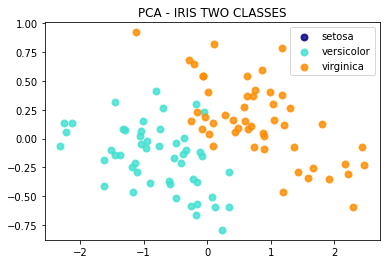

<Figure size 432x288 with 0 Axes>

In [5]:
# visualizing the new dataset using PCA
from sklearn.decomposition import PCA

X_iris= df_iris_x.to_numpy()
Y_iris= np.concatenate(df_iris_y.to_numpy())

pca= PCA(n_components= 2)
X_pca= pca.fit(X_iris).transform(X_iris)

colors= ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X_pca[Y_iris == i, 0], X_pca[Y_iris == i, 1], color=color, alpha=.8, lw=2, label=target_name)
    
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA - IRIS TWO CLASSES')
plt.figure()

In [6]:
# ML model - Random forest
import sklearn.ensemble

train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(df_iris_x,df_iris_y,train_size=0.80,random_state=1234)

rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)
rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.85

In [8]:
# ML model - XGBoost random forest
import xgboost as xgb

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.85

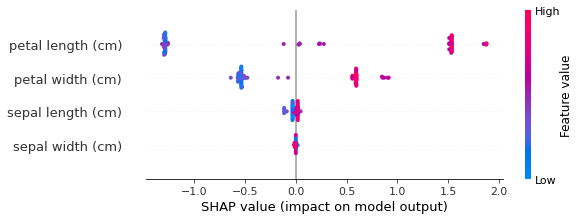

In [10]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Wine dataset

In [19]:
wine= pd.read_csv('datasets/wine.data',header=None)

wine.columns= ['target','alcohol','malicAcid','ash','ashalcalinity','magnesium','totalPhenols','flavanoids','nonFlavanoidPhenols','proanthocyanins',
               'colorIntensity','hue','od280_od315','proline']

wine= wine[wine['target']!= 3].reset_index(drop= True)

x_wine= wine.iloc[:,1:len(wine.columns)].copy()
y_wine= np.asarray(wine['target'])

x_wine.shape

(130, 13)

In [20]:
x_wine= far.pre_proc_fillna_num_fts(x_wine, x_wine.columns, num_type='mean')

x_wine= far.normalize_selected_cols(x_wine, x_wine.columns)

In [22]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_wine,y_wine,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')
xgb_model.fit(train, labels_train)
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

1.0

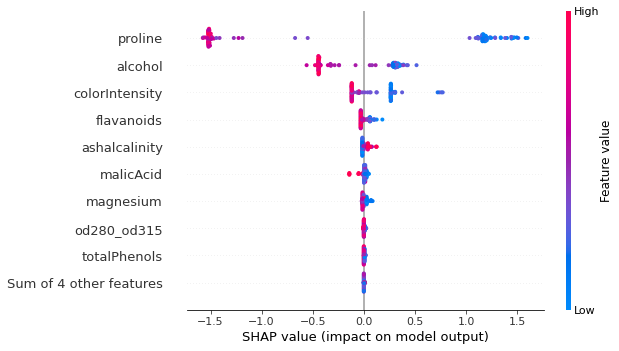

In [24]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Titanic dataset

In [11]:
ds= zf.ZipFile('datasets/titanic.zip')

train_data= pd.read_csv(ds.open('train.csv'))
test_data= pd.read_csv(ds.open('test.csv'))

X_all= pd.concat([train_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']],
                   test_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]]).set_index('PassengerId')

y_train= train_data[['PassengerId','Survived']].set_index('PassengerId')['Survived']

numeric_columns= ['Age','SibSp','Parch','Fare']
categor_columns= list(filter(lambda x:x not in numeric_columns,X_all.columns))

X_train= X_all.iloc[:len(train_data),:].copy()
X_test= X_all.iloc[len(train_data):].copy()

In [12]:
import Ft_Att_Rank as far

X_train= far.pre_proc_fillna_num_fts(X_train,numeric_columns,num_type='median')
X_train= far.pre_proc_fillna_cat_fts(X_train,categor_columns,cat_type='mode')

X_train_ohe= pd.get_dummies(X_train,columns=categor_columns)

X_train= far.normalize_selected_cols(X_train, numeric_columns)
X_train_ohe= far.normalize_selected_cols(X_train_ohe, numeric_columns)

X_train.shape

(891, 7)

In [13]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.8379888268156425

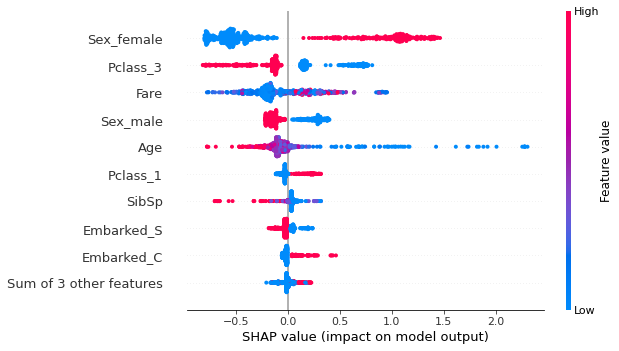

In [14]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Heartrisk dataset

In [15]:
ds= zf.ZipFile('datasets/heart.zip')

heart_data= pd.read_csv(ds.open('heart.csv'))

x_heart= heart_data.iloc[:,:(len(heart_data.columns)-1)].copy()
y_heart= np.asarray(heart_data['target'])

x_heart.shape

(303, 13)

In [16]:
x_heart= far.pre_proc_fillna_num_fts(x_heart, x_heart.columns,num_type='mean')

x_heart= far.normalize_selected_cols(x_heart, x_heart.columns)

In [17]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_heart,y_heart,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(train, labels_train)
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.7377049180327869

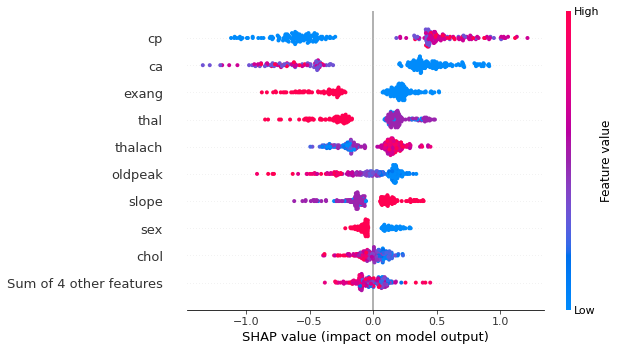

In [18]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Breast cancer Wisconsin dataset

In [25]:
wdbc= sklearn.datasets.load_breast_cancer()

X_wb_cancer= pd.DataFrame(wdbc.data,columns=wdbc.feature_names)
Y_wb_cancer= wdbc.target

X_wb_cancer.shape

(569, 30)

In [26]:
X_wb_cancer= far.pre_proc_fillna_num_fts(X_wb_cancer,wdbc.feature_names,num_type='mean')

X_wb_cancer= far.normalize_selected_cols(X_wb_cancer, wdbc.feature_names)

In [27]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(X_wb_cancer,Y_wb_cancer,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(train, labels_train)
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.9298245614035088

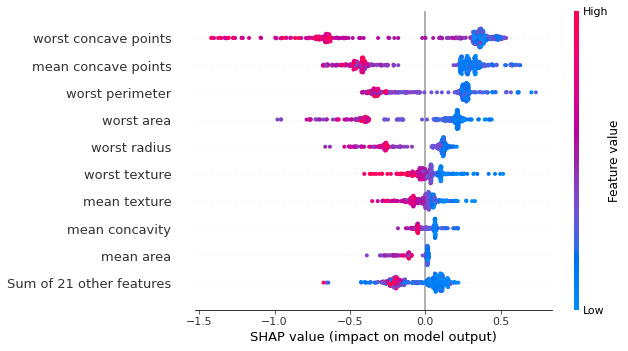

In [28]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Drug consumption dataset

In [29]:
demographic_columns= ['Age','Gender','Education','Country','Ethnicity']
personality_columns= ['Neuroticism','Extraversion','Openness to experience','Agreeableness','Conscientiousness','Impulsiveness','Sensation seeking']

drugs_columns= ['Alcohol','Amphetamines','Amyl nitrite','Benzodiazepine','Caffeine','Cannabis','Chocolate','Cocaine','Crack','Ecstasy','Heroin','Ketamine',
    'Legal highs','Lysergic acid diethylamide','Methadone','Magic mushrooms','Nicotine','Fictitious drug Semeron','Volatile substance abuse']

drugs_legal= ['Alcohol', 'Caffeine', 'Chocolate', 'Nicotine']

feature_columns= demographic_columns + personality_columns

drugs_illegal= [drug for drug in drugs_columns if drug not in drugs_legal]

all_columns= feature_columns + drugs_columns

drugs_data= pd.read_csv('datasets/drug_consumption.data',names=["ID"]+all_columns).set_index("ID")

drugs_data.head()

,Age,Gender,Education,Country,Ethnicity,Neuroticism,Extraversion,Openness to experience,Agreeableness,Conscientiousness,...,Ecstasy,Heroin,Ketamine,Legal highs,Lysergic acid diethylamide,Methadone,Magic mushrooms,Nicotine,Fictitious drug Semeron,Volatile substance abuse
ID,,,,,,,,,,,,,,,,,,,,,
1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


# Arrhythmia dataset

In [30]:
arrhy= pd.read_csv('datasets/arrhythmia.data',header=None)

arrhy

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,53,1,160,70,80,199,382,154,117,-37,...,0.0,4.3,-5.0,0.0,0.0,0.7,0.6,-4.4,-0.5,1
448,37,0,190,85,100,137,361,201,73,86,...,0.0,15.6,-1.6,0.0,0.0,0.4,2.4,38.0,62.4,10
449,36,0,166,68,108,176,365,194,116,-85,...,0.0,16.3,-28.6,0.0,0.0,1.5,1.0,-44.2,-33.2,2
450,32,1,155,55,93,106,386,218,63,54,...,-0.4,12.0,-0.7,0.0,0.0,0.5,2.4,25.0,46.6,1
